# Riyadh Restaurants — Exploratory Data Analysis
**Student:** a  
**Dataset:** [Riyadh Restaurants 20K — Kaggle](https://www.kaggle.com/datasets/fahd09/riyadh-restaurants-20k/data)  
**Goal:** Analyze restaurant data in Riyadh to find the most common cuisines (especially Asian food), how price affects ratings, and how restaurants are spread across the city.



In [1]:
# import Libraries
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Make charts look clean
sns.set_theme(style="whitegrid")

# Consistent visual style
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 110,
})

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Load the Dataset

The dataset was downloaded using `kagglehub` and loaded into a pandas DataFrame.

In [2]:
import kagglehub
import os
# Download the dataset from Kaggle
path = kagglehub.dataset_download("fahd09/riyadh-restaurants-20k")

# Load the CSV file
csv_path = os.path.join(path, "riyadh_resturants_clean.csv")
df_raw = pd.read_csv(csv_path)

# Display basic information
print(f"Dataset shape: {df_raw.shape}")
print(f"\nColumns: {df_raw.columns.tolist() }")

ModuleNotFoundError: No module named 'kagglehub'

## Initial Data Exploration

Before cleaning the dataset, we examined its structure by reviewing the number of rows and columns, data types, summary statistics, and missing values.

In [ ]:
# the first 5 row
df_raw.head()

,name,categories,address,lat,lng,price,likes,photos,tips,rating,ratingSignals
0,مطعم وقت الشواية,Afghan Restaurant,"الرياض 14723, المملكة العربية السعودية",24.518983,46.656981,Moderate,0.0,0,0,NaN,NaN
1,ديوانية عكاظ,Café,"الرياض 14726, المملكة العربية السعودية",24.518511,46.669149,Cheap,0.0,2,0,NaN,NaN
2,شاهي جمر راعي الجمس,Coffee Shop,"الرياض 14726, المملكة العربية السعودية",24.519314,46.670041,Cheap,0.0,0,0,NaN,NaN
3,غدير الشام,Afghan Restaurant,المملكة العربية السعودية,24.519520,46.671660,Moderate,0.0,0,0,NaN,NaN
4,Dunkin',Donut Shop,"الرياض, المملكة العربية السعودية",24.525001,46.433944,Cheap,29.0,90,1,8.9,32.0


In [ ]:
# Dataset information
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19361 entries, 0 to 19360
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           19361 non-null  object 
 1   categories     19361 non-null  object 
 2   address        19361 non-null  object 
 3   lat            19361 non-null  float64
 4   lng            19361 non-null  float64
 5   price          17846 non-null  object 
 6   likes          19359 non-null  float64
 7   photos         19361 non-null  int64  
 8   tips           19361 non-null  int64  
 9   rating         7949 non-null   float64
 10  ratingSignals  7949 non-null   float64
dtypes: float64(5), int64(2), object(4)
memory usage: 1.6+ MB


In [ ]:
# Summary statistics
df_raw.describe(include="all")

,name,categories,address,lat,lng,price,likes,photos,tips,rating,ratingSignals
count,19361,19361,19361,19361.000000,19361.000000,17846,19359.000000,19361.000000,19361.000000,7949.000000,7949.000000
unique,14520,1130,8996,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN
top,Dunkin' Donuts (دانكن دونتس),Coffee Shop,المملكة العربية السعودية,NaN,NaN,Cheap,NaN,NaN,NaN,NaN,NaN
freq,120,2110,3845,NaN,NaN,13499,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,24.722588,46.697338,NaN,63.609639,167.775735,17.090853,7.536231,201.637313
std,NaN,NaN,NaN,0.082220,0.074112,NaN,291.028125,985.424550,75.456881,0.942969,552.225144
min,NaN,NaN,NaN,24.469683,46.272777,NaN,0.000000,0.000000,0.000000,4.400000,0.000000
25%,NaN,NaN,NaN,24.674721,46.643255,NaN,0.000000,1.000000,0.000000,6.900000,14.000000
50%,NaN,NaN,NaN,24.737781,46.693637,NaN,3.000000,4.000000,1.000000,7.600000,38.000000
75%,NaN,NaN,NaN,24.784026,46.753452,NaN,17.000000,24.000000,5.000000,8.200000,143.000000


In [ ]:
# Check missing values
missing = df_raw.isnull().sum()

missing_pct = ( df_raw.isnull().sum() / len(df_raw) * 100).round(2)

missing_table = pd.DataFrame({ "Missing Count": missing, "Missing Percentage": missing_pct})

missing_table.sort_values( by="Missing Count", ascending=False)

,Missing Count,Missing Percentage
rating,11412,58.94
ratingSignals,11412,58.94
price,1515,7.83
likes,2,0.01
address,0,0.00
name,0,0.00
categories,0,0.00
lat,0,0.00
lng,0,0.00
tips,0,0.00


## Data Cleaning

Before performing exploratory data analysis, the dataset was cleaned to improve its quality. The cleaning process included checking for duplicate records, handling missing values where appropriate, and removing unnecessary columns that are not relevant to the project objectives.

In [ ]:
# Create a copy of the dataset so the original data remains unchanged.
df_clean = df_raw.copy()

In [ ]:
# Check for duplicate rows
print("Duplicate rows before cleaning:", df_clean.duplicated().sum())

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Verify duplicates were removed
print("Duplicate rows after cleaning:", df_clean.duplicated().sum())

Duplicate rows before cleaning: 1
Duplicate rows after cleaning: 0


In [ ]:
# Fill missing values in the 'likes' column with 0
# Missing likes most likely indicate no recorded likes.
df_clean["likes"] = df_clean["likes"].fillna(0)

In [ ]:
# Remove 'ratingSignals' because it is not required
# for the objectives of this project.
df_clean = df_clean.drop(columns=["ratingSignals"])

In [ ]:
# Check remaining missing values after cleaning
missing = pd.DataFrame({ "Missing Count": df_clean.isnull().sum(), "Missing Percentage": ( df_clean.isnull().sum() / len(df_clean) * 100 ).round(2) })

missing.sort_values(by="Missing Count", ascending=False)

,Missing Count,Missing Percentage
rating,11412,58.95
price,1515,7.83
categories,0,0.00
name,0,0.00
lat,0,0.00
address,0,0.00
lng,0,0.00
likes,0,0.00
photos,0,0.00
tips,0,0.00


### Cleaning Summary

- Removed duplicate records.
- Filled missing values in the **likes** column with 0.
- Removed the **ratingSignals** column because it is not required for this analysis.
- Missing values in **rating** and **price** were intentionally kept because filling them could introduce bias. These missing values will be handled only when needed during specific analyses.

rating: More than half of the restaurants have no rating. Filling these values with the median would create thousands of artificial ratings and bias the analysis.


price: Since one of the project goals is to study the relationship between price and rating, keeping only restaurants with known price information during that analysis is more appropriate than inventing a new category like "Unknown".

## 6. Exploratory Data Analysis (EDA)

This section explores the cleaned dataset to identify patterns and relationships. The analysis focuses on restaurant ratings, price levels, customer engagement, restaurant categories, and the geographical distribution of restaurants across Riyadh.

In [ ]:
#Dataset Overview after cleaning
print("Dataset shape:", df_clean.shape)
df_clean.dtypes

Dataset shape: (19360, 10)


,0
name,object
categories,object
address,object
lat,float64
lng,float64
price,object
likes,float64
photos,int64
tips,int64
rating,float64


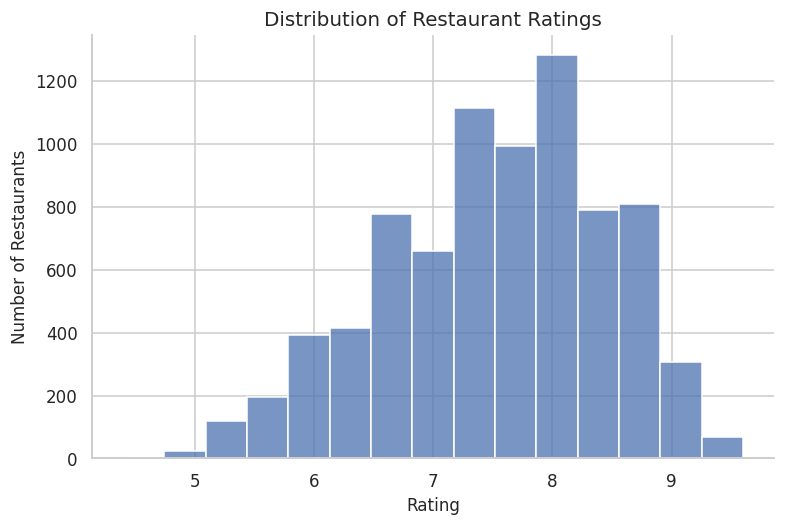

In [ ]:
#how restaurant ratings are distributed across the dataset.
plt.figure(figsize=(8,5))

sns.histplot(data=df_clean, x="rating", bins=15)

plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")

plt.show()

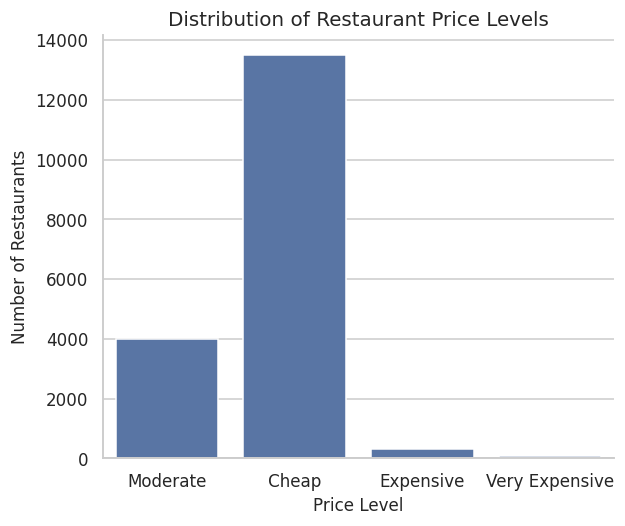

In [ ]:
#how restaurants are distributed across different price levels.
plt.figure(figsize=(6,5))

sns.countplot(data=df_clean, x="price")

plt.title("Distribution of Restaurant Price Levels")
plt.xlabel("Price Level")
plt.ylabel("Number of Restaurants")

plt.show()

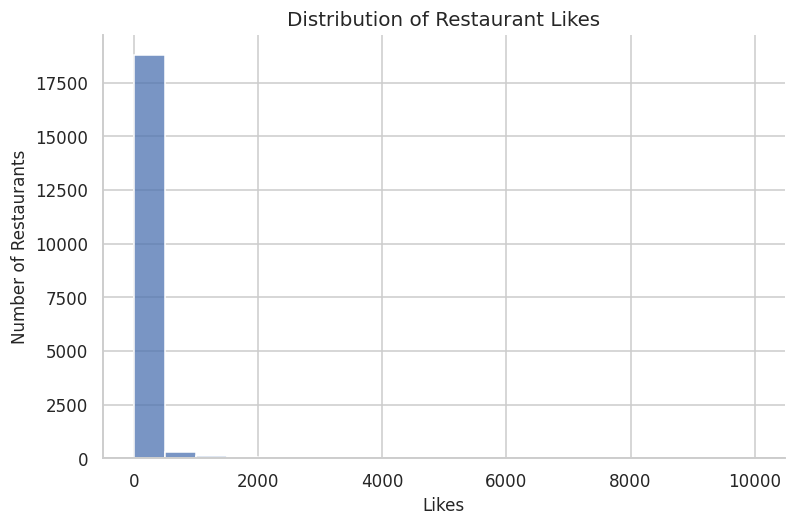

In [ ]:
#Customer likes indicate the popularity of restaurants.
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_clean,
    x="likes",
    bins=20
)

plt.title("Distribution of Restaurant Likes")
plt.xlabel("Likes")
plt.ylabel("Number of Restaurants")

plt.show()

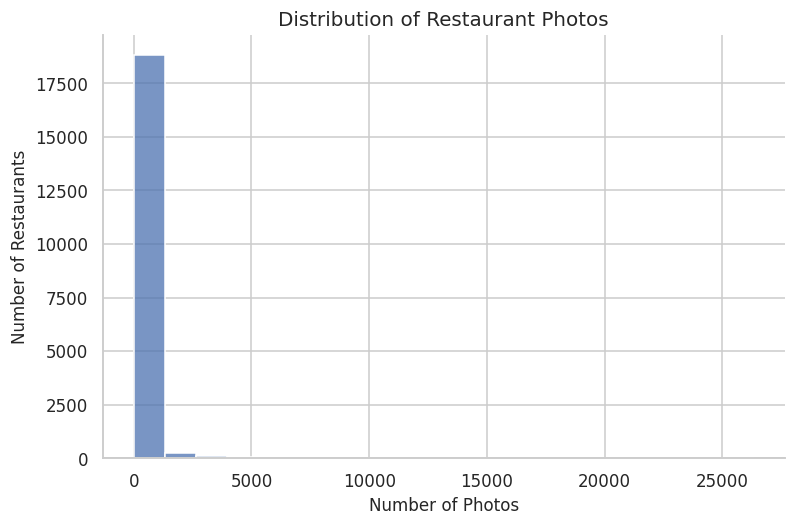

In [ ]:
 #how many photos restaurants typically have.
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_clean,
    x="photos",
    bins=20
)

plt.title("Distribution of Restaurant Photos")
plt.xlabel("Number of Photos")
plt.ylabel("Number of Restaurants")

plt.show()

In [ ]:
#Relationship Between Price and Ratings
#This analysis explores whether restaurant price levels are associated with higher or lower ratings.
df_clean.groupby("price")["rating"].agg(["count", "mean", "median"])

,count,mean,median
price,,,
Cheap,5656,7.606772,7.7
Expensive,188,7.682447,7.8
Moderate,1525,7.342623,7.4
Very Expensive,41,7.619512,7.7


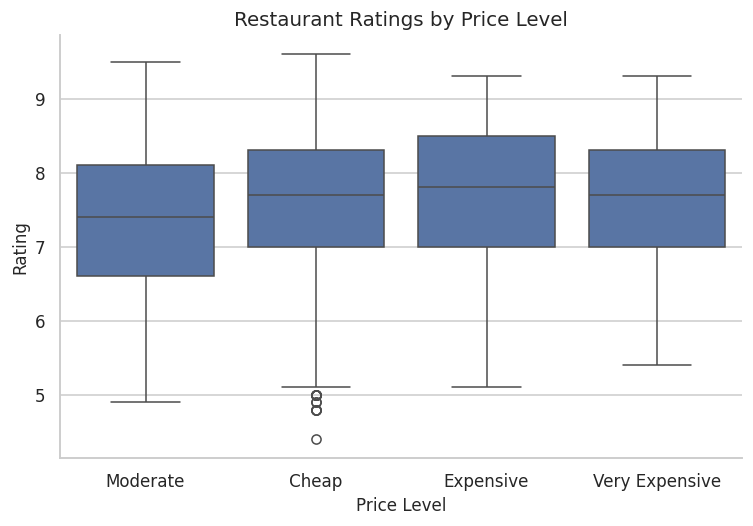

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df_clean, x="price", y="rating")

plt.title("Restaurant Ratings by Price Level")
plt.xlabel("Price Level")
plt.ylabel("Rating")

plt.show()

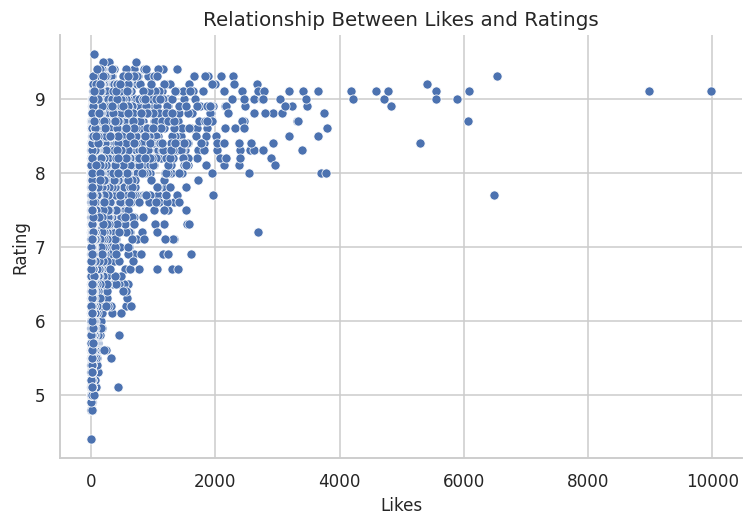

In [ ]:
#Relationship Between Likes and Ratings
#This scatter plot explores whether restaurants with more likes tend to receive higher ratings.
plt.figure(figsize=(8,5))

sns.scatterplot(data=df_clean, x="likes", y="rating")

plt.title("Relationship Between Likes and Ratings")
plt.xlabel("Likes")
plt.ylabel("Rating")

plt.show()

##Correlation Analysis


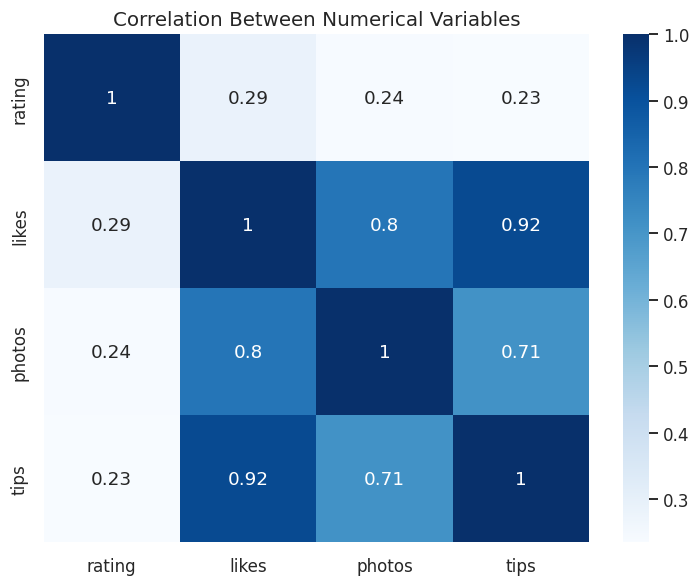

In [ ]:
plt.figure(figsize=(8,6))

corr = df_clean[["rating", "likes", "photos", "tips"]].corr()

sns.heatmap(corr, annot=True, cmap="Blues")

plt.title("Correlation Between Numerical Variables")

plt.show()

##Geographical Distribution of Restaurants


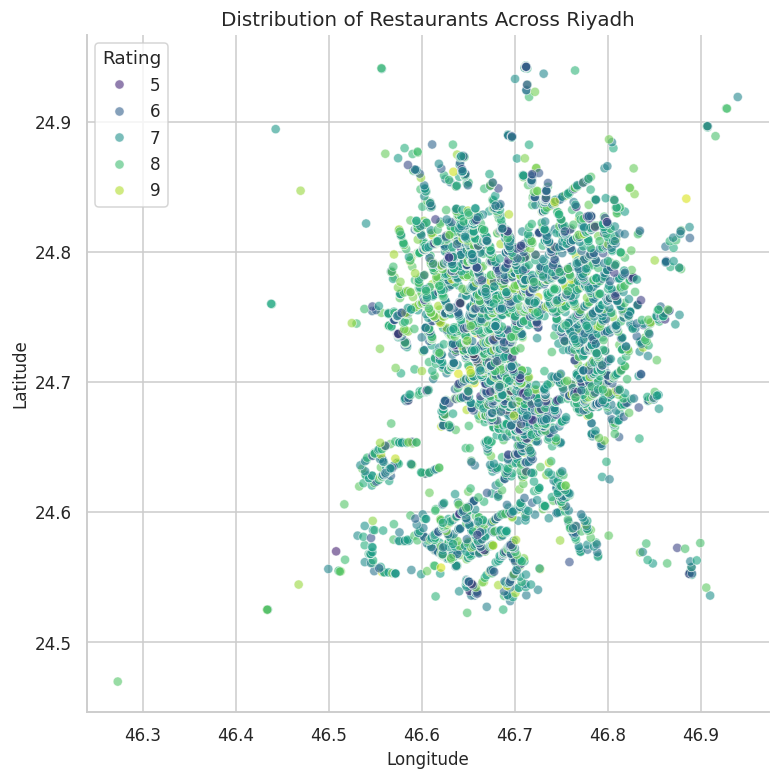

In [ ]:
#This visualization shows where restaurants are located across Riyadh. Colors represent restaurant ratings.
plt.figure(figsize=(8,8))

sns.scatterplot(
    data=df_clean,
    x="lng",
    y="lat",
    hue="rating",
    palette="viridis",
    alpha=0.6
)

plt.title("Distribution of Restaurants Across Riyadh")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.legend(title="Rating")

plt.show()

##Most Common Restaurant Categories

In [ ]:
# This analysis identifies the most common categories in Riyadh.
all_categories = (
    df_clean["categories"]
    .str.split(",")
    .explode()
    .str.strip()
)

category_counts = all_categories.value_counts()

category_counts.head(15)

,count
categories,
Coffee Shop,2872
Café,2647
Fast Food Restaurant,1178
Middle Eastern Restaurant,1168
Dessert Shop,1082
Burger Joint,999
Food Truck,955
Bakery,886
Restaurant,863


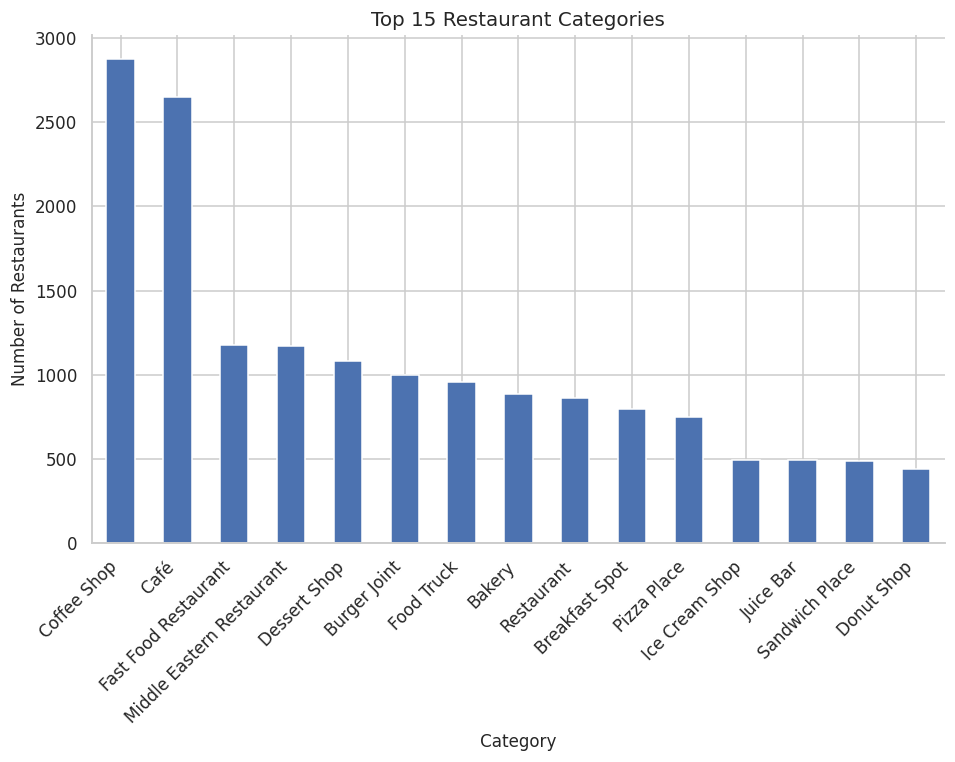

In [ ]:
plt.figure(figsize=(10,6))

category_counts.head(15).plot(kind="bar")

plt.title("Top 15 Restaurant Categories")
plt.xlabel("Category")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=45, ha="right")

plt.show()

##Asian Restaurant Analysis
This project aims to explore Asian restaurants in Riyadh, this section identifies Asian restaurants, compares them with non-Asian restaurants, and examines the most common Asian restaurant categories.

In [ ]:
asian_categories = [
    "Japanese Restaurant",
    "Chinese Restaurant",
    "Korean Restaurant",
    "Thai Restaurant",
    "Indian Restaurant",
    "Vietnamese Restaurant",
    "Asian Restaurant",
    "Sushi Restaurant",
    "Ramen Restaurant",
    "Dim Sum Restaurant"
]

df_clean["Asian"] = df_clean["categories"].apply(
    lambda x: any(cat in x for cat in asian_categories)
)

In [ ]:
asian_counts = df_clean["Asian"].value_counts()

asian_percentage = (
    df_clean["Asian"]
    .value_counts(normalize=True)
    * 100
).round(2)

print("Restaurant Counts:")
print(asian_counts)

print("\nPercentage:")
print(asian_percentage)

Restaurant Counts:
Asian
False    18717
True       643
Name: count, dtype: int64

Percentage:
Asian
False    96.68
True      3.32
Name: proportion, dtype: float64


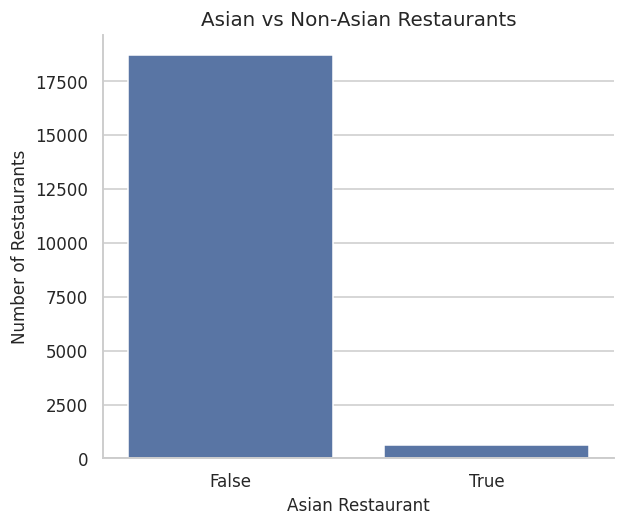

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df_clean,
    x="Asian"
)

plt.title("Asian vs Non-Asian Restaurants")
plt.xlabel("Asian Restaurant")
plt.ylabel("Number of Restaurants")

plt.show()

In [ ]:
asian_df = df_clean[df_clean["Asian"]]

asian_category_counts = (
    asian_df["categories"]
    .str.split(",")
    .explode()
    .str.strip()
)

# Keep only Asian categories
asian_category_counts = asian_category_counts[
    asian_category_counts.isin(asian_categories)
]

asian_category_counts = asian_category_counts.value_counts()

asian_category_counts

,count
categories,
Indian Restaurant,234
Asian Restaurant,203
Chinese Restaurant,81
Japanese Restaurant,57
Sushi Restaurant,45
Thai Restaurant,18
Dim Sum Restaurant,4
Vietnamese Restaurant,3
Korean Restaurant,2


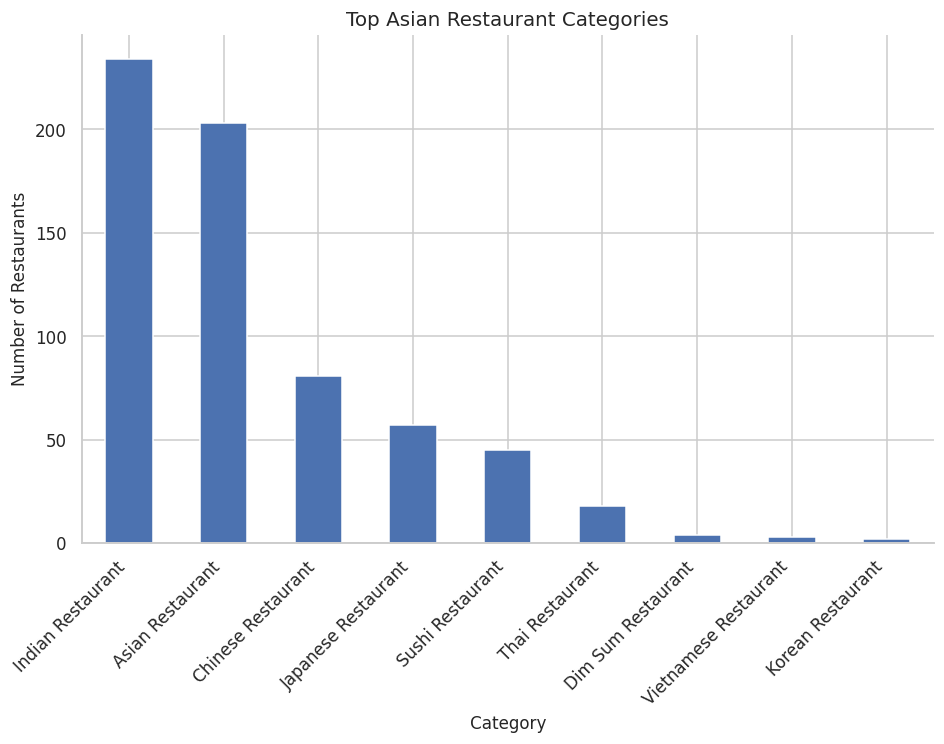

In [ ]:
plt.figure(figsize=(10,6))

asian_category_counts.plot(kind="bar")

plt.title("Top Asian Restaurant Categories")

plt.xlabel("Category")

plt.ylabel("Number of Restaurants")

plt.xticks(rotation=45, ha="right")

plt.show()

In [ ]:
price_summary = (
    df_clean
    .groupby("price")["rating"]
    .agg(["count", "mean", "median"])
)

price_summary

,count,mean,median
price,,,
Cheap,5656,7.606772,7.7
Expensive,188,7.682447,7.8
Moderate,1525,7.342623,7.4
Very Expensive,41,7.619512,7.7


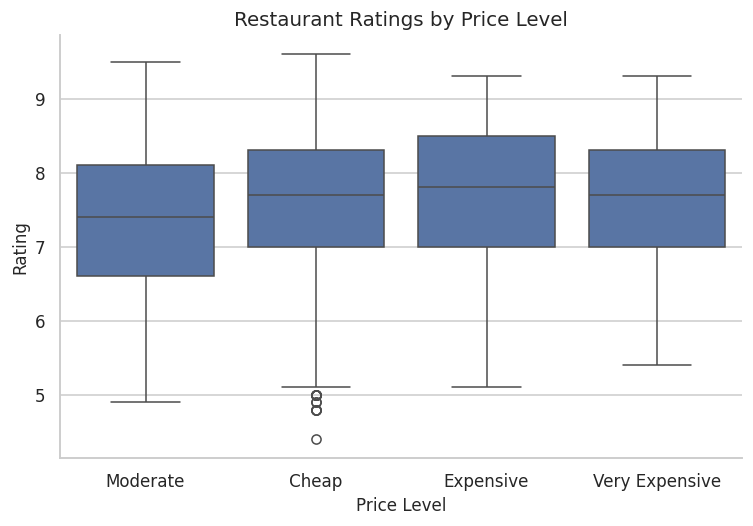

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df_clean, x="price", y="rating")

plt.title("Restaurant Ratings by Price Level")
plt.xlabel("Price Level")
plt.ylabel("Rating")

plt.show()

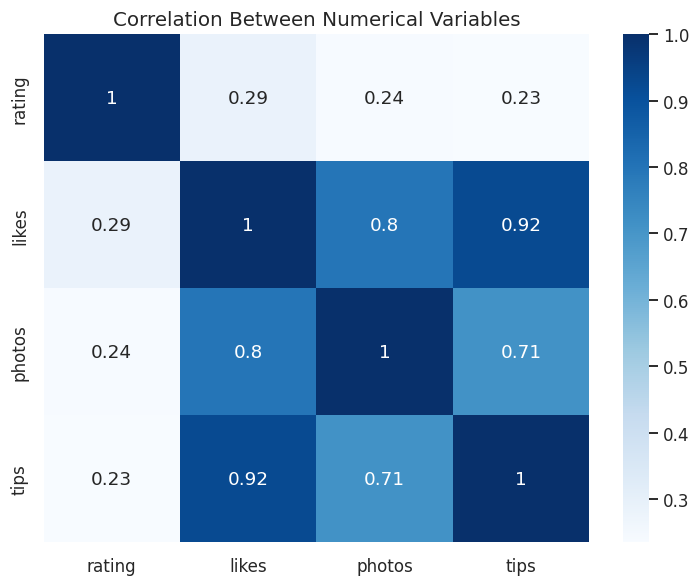

In [ ]:
plt.figure(figsize=(8,6))

corr = df_clean[["rating", "likes", "photos", "tips"]].corr()

sns.heatmap(corr,
            annot=True,
            cmap="Blues")

plt.title("Correlation Between Numerical Variables")

plt.show()

In [ ]:
# Convert True/False into 1/0
df_clean["Asian_Numeric"] = df_clean["Asian"].astype(int)

# Create popularity score
df_clean["Popularity"] = (
    df_clean["likes"] +
    df_clean["tips"]
)

# Preview
df_clean[
    [
        "Asian",
        "Asian_Numeric",
        "likes",
        "tips",
        "Popularity"
    ]
].head()

,Asian,Asian_Numeric,likes,tips,Popularity
0,False,0,0.0,0,0.0
1,False,0,0.0,0,0.0
2,False,0,0.0,0,0.0
3,False,0,0.0,0,0.0
4,False,0,29.0,1,30.0


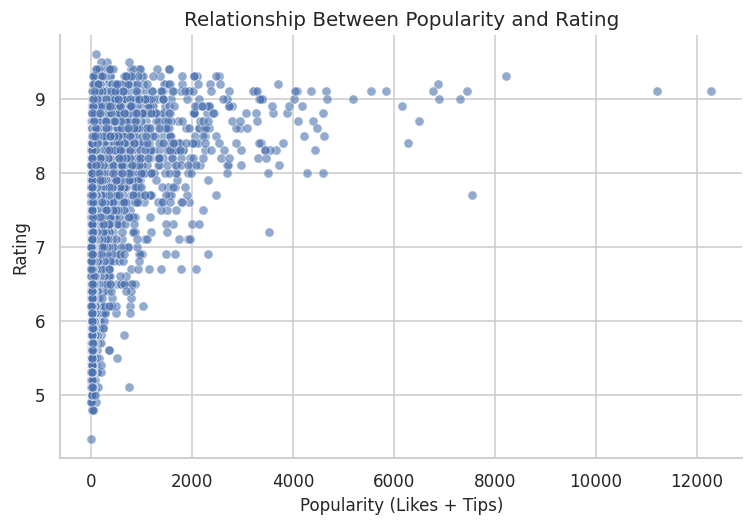

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_clean,
    x="Popularity",
    y="rating",
    alpha=0.6
)

plt.title("Relationship Between Popularity and Rating")
plt.xlabel("Popularity (Likes + Tips)")
plt.ylabel("Rating")

plt.show()

##Key Insights:
1. The restaurant market in Riyadh is dominated by a small number of restaurant categories, with cafés, bakeries, and fast-food restaurants appearing most frequently.

2. Asian restaurants represent a relatively small portion of all restaurants in the dataset (approximately 3–4%), with Indian, Japanese, and Chinese restaurants being among the most common Asian categories.

3. Restaurant ratings are generally high, with most ratings concentrated between 3.5 and 5.0.

4. Price level does not strongly determine restaurant ratings. More expensive restaurants do not always receive higher ratings than lower-priced restaurants.

5. Customer engagement metrics such as likes and tips show a positive relationship with restaurant ratings.

6. Restaurants are not evenly distributed across Riyadh. Instead, they are concentrated in specific areas of the city.

7. The engineered Popularity feature (Likes + Tips) indicates that restaurants with greater customer engagement tend to achieve better ratings.

##Conclusion:

This project explored restaurant data from Riyadh using exploratory data analysis (EDA). The analysis included data cleaning, feature engineering, statistical summaries, and visualizations.

The results showed that restaurant ratings are generally high across the city, while price level alone is not a strong indicator of customer satisfaction. Asian restaurants make up a smaller portion of the market but remain an important cuisine category. Additionally, customer engagement measures such as likes and tips appear to be associated with higher restaurant ratings.